## Results from decay_endmax_fidelity.jld2

In [1]:
using Plots, JLD2, LaTeXStrings, FileIO,  PGFPlotsX, Polynomials
# pgfplotsx()

# @load "/home/agfleischhauer/roq68sum/rydberg_qec/codework/results_data/2atoms/decay_endmax_fidelity.jld2"
@load "/Users/akashmalemath/Documents/master_work/rydberg_thesis/rydberg_qec/codework/2atoms/results_data/decay_endmax_fidelity.jld2"
# @load "Z:/master_work/rydberg_qec/codework/2atoms/results_data/decay_endmax_fidelity.jld2"

decay = decay
sweep_rate = sweep_rate
fidelity_end = fidelity_end
max_fidelity = max_fidelity;

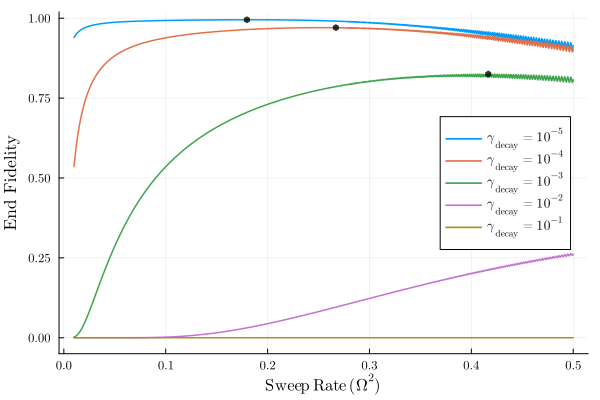

In [25]:
fig = plot(sweep_rate,fidelity_end[1,:],fontfamily="Computer Modern", fontsize=10, label=L"$\gamma_{\mathrm{decay}} = 10^{-5}$",
xlabel=L"\mathrm{Sweep\; Rate\;(\Omega^2)}",ylabel="End Fidelity",legend=:right,grid=true,ylim=[-0.05,1.02],lw=1.5)
plot!(sweep_rate,fidelity_end[2,:],label=L"$\gamma_{\mathrm{decay}} = 10^{-4}$",lw=1.5)
plot!(sweep_rate,fidelity_end[3,:],label=L"$\gamma_{\mathrm{decay}} = 10^{-3}$",lw=1.5)
plot!(sweep_rate,fidelity_end[4,:],label=L"$\gamma_{\mathrm{decay}} = 10^{-2}$",lw=1.5)
plot!(sweep_rate,fidelity_end[5,:],label=L"$\gamma_{\mathrm{decay}} = 10^{-1}$",lw=1.5)
#mark the ymax points for all the curves
for i in 1:3
    ymax = findmax(fidelity_end[i,:])
    scatter!([sweep_rate[ymax[2]]],[ymax[1]],label="",markershape=:hexagon,markersize=3.5,color=:black,alpha=0.8,legendfontsize=9)
end
# annotation for the points
# annotate!([(sweep_rate[3],fidelity_end[1,3]+0.05,text("$(round(fidelity_end[1,3],digits=3))",:black,8,:center)),
# (sweep_rate[3],fidelity_end[2,3]+0.05,text("$(round(fidelity_end[2,3],digits=3))",:black,8,:center)),
# (sweep_rate[3],fidelity_end[3,3]+0.05,text("$(round(fidelity_end[3,3],digits=3))",:black,8,:center)),
# (sweep_rate[3],fidelity_end[4,3]+0.05,text("$(round(fidelity_end[4,3],digits=3))",:black,8,:center)),
# (sweep_rate[3],fidelity_end[5,3]+0.05,text("$(round(fidelity_end[5,3],digits=3))",:black,8,:center))])
# annotation for the points end
# title!("End fidelity for a sweep rate")

savefig(fig,"/Users/akashmalemath/Documents/master_work/rydberg_thesis/rydberg_qec/images/part3/num_sim/2atom_end_fidelity_vs_sweep_rate.pdf")
display(fig)

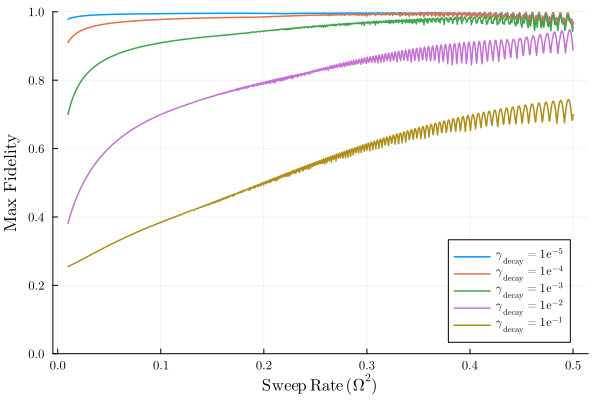

In [3]:
fig2 = plot(sweep_rate,max_fidelity[1,:],fontfamily="Computer Modern", fontsize=10, label=L"$\gamma_{\mathrm{decay}} = 1\mathrm{e}^{-5}$",
xlabel=L"\mathrm{Sweep\; Rate\;(\Omega^2)}",ylabel="Max Fidelity",legend=:bottomright,grid=true,ylim=[-0.0,1],lw=1.5)#,title="Max fidelity for a sweep rate")
plot!(sweep_rate,max_fidelity[2,:], label=L"$\gamma_{\mathrm{decay}} = 1\mathrm{e}^{-4}$",lw=1.5)
plot!(sweep_rate,max_fidelity[3,:], label=L"$\gamma_{\mathrm{decay}} = 1\mathrm{e}^{-3}$",lw=1.5)
plot!(sweep_rate,max_fidelity[4,:], label=L"$\gamma_{\mathrm{decay}} = 1\mathrm{e}^{-2}$",lw=1.5) 
plot!(sweep_rate,max_fidelity[5,:], label=L"$\gamma_{\mathrm{decay}} = 1\mathrm{e}^{-1}$",lw=1.5)
savefig(fig2,"/Users/akashmalemath/Documents/master_work/rydberg_thesis/rydberg_qec/images/part3/num_sim/2atom_max_fidelity_vs_sweep_rate.pdf")
display(fig2)

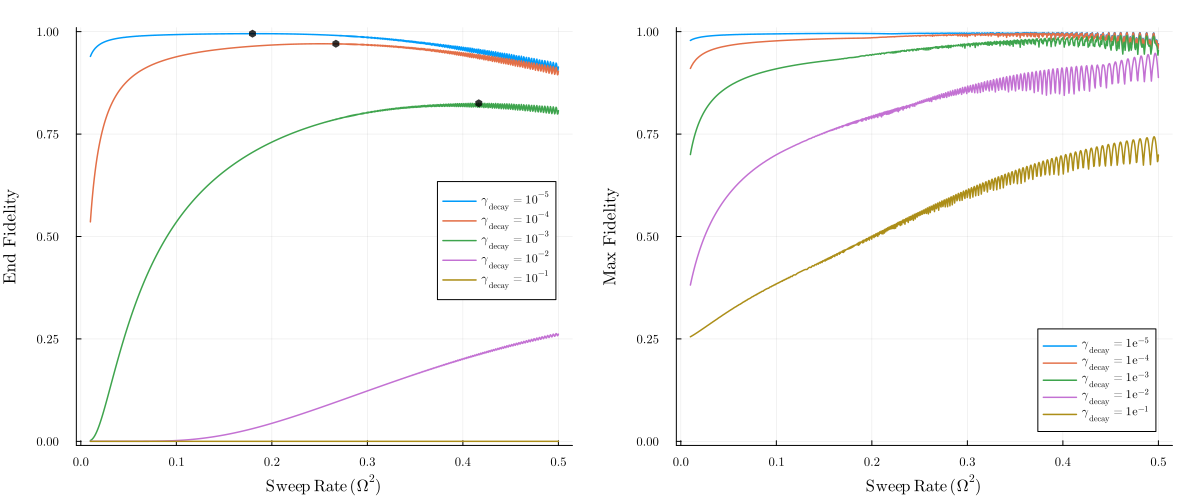

In [4]:
p = plot(fig, fig2;
    layout=(1,2),
    link=:y,                # share y-scale
    size=(1200,500),
    ylim=[-0.01,1.01],
    markersize=4,
    fontsize=10,
    fontfamily="Computer Modern",
    margin=5Plots.mm)
savefig(p, "/Users/akashmalemath/Documents/master_work/rydberg_thesis/rydberg_qec/images/part3/num_sim/full_2_in_1.pdf")
display(p)

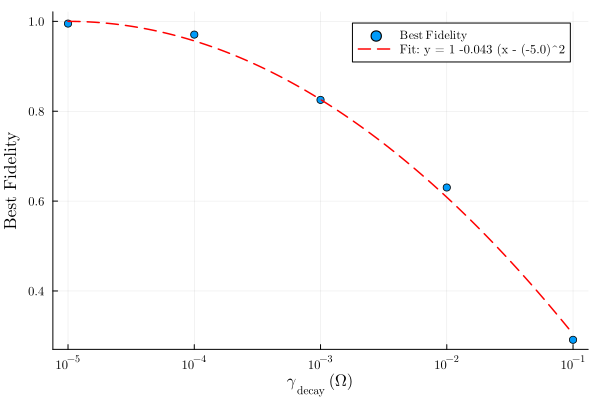

In [5]:
best_fidelity = maximum(fidelity_end[:,1:length(sweep_rate)],dims=2);
best_sweep_rate = []
for i in 1:length(decay)
    max_index = argmax(fidelity_end[i,1:length(sweep_rate)])
    push!(best_sweep_rate, sweep_rate[max_index])
end

best_fidelity[4] =  0.63025419731297
best_fidelity[5] = 0.29129329475756144
fig = scatter(decay,best_fidelity,xscale=:log10, fontfamily="Computer Modern", fontsize=10, grid=true,
label=L"\mathrm{Best\;Fidelity}", xlabel=L"\gamma_{\textrm{decay}}\;(\Omega)", ylabel="Best Fidelity",legend=:true, xticks=[1e-5, 1e-4, 1e-3, 1e-2, 1e-1])#, title="Best Fidelity Obtained vs Decay")
#fit a polynomial curve to the data
x = log10.(decay); y = vec(best_fidelity)
x0 = minimum(x)
ϕ  = (x .- x0).^2
c  = (ϕ \ (1 .- y))         # linear least squares
x_fit = range(minimum(x), maximum(x), length=300)
y_fit = 1 .- c .* (x_fit .- x0).^2

# println(coeffs(p))
c_round = round(c, digits=3)
x0_round = round(x0, digits=3)


plot!(10 .^ x_fit, y_fit, label="Fit: y = 1 -$c_round (x - ($x0_round)^2", lw=1.5, lc=:red, linestyle=:dash)

savefig(fig, "/Users/akashmalemath/Documents/master_work/rydberg_thesis/rydberg_qec/images/part3/num_sim/best_fidelity_vs_decay.pdf")
display(fig)

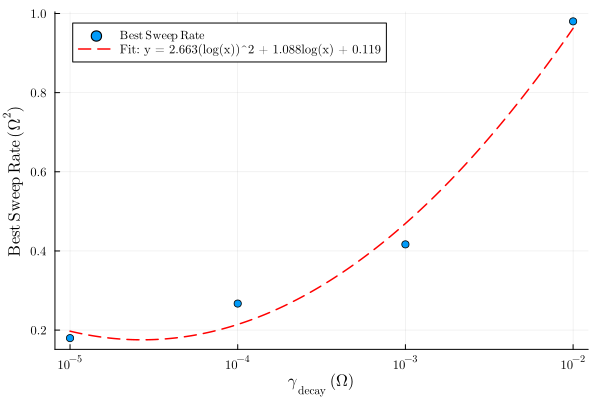

[2.6632770879618772, 1.0884673716411537, 0.11905404236791822]


"/Users/akashmalemath/Documents/master_work/rydberg_thesis/rydberg_qec/images/part3/num_sim/best_sweep_rate_vs_decay.pdf"

In [6]:
best_sweep_rate[4] = 0.980140093395597
fig2 = scatter(decay[1:4], best_sweep_rate[1:4];
    xscale=:log10, label=L"\mathrm{Best\;Sweep\;Rate}", fontsize=10, fontfamily="Computer Modern",
    xlabel=L"\gamma_{\textrm{decay}}\;(\Omega)", ylabel=L"\mathrm{Best\;Sweep\;Rate}\;(\Omega^2)",
    grid=true,
    legend=true, xticks=[1e-5, 1e-4, 1e-3, 1e-2, 1e-1])

# fit y ≈ a*log10(x) + b
x = log10.(decay[1:4])
y = Float64.(best_sweep_rate[1:4])
p = fit(Polynomial, x, y, 2)  # linear in log10(x)
println(coeffs(p))

x_fit_log = range(minimum(x), maximum(x), length=200)
y_fit = p.(x_fit_log)

# plot fit vs linear x; the axis handles the log scale
plot!(10 .^ x_fit_log, y_fit; label="Fit: y = $(round(p.coeffs[1], digits=3))(log(x))^2 + $(round(p.coeffs[2], digits=3))log(x) + $(round(p.coeffs[3], digits=3))", color=:red, lw=1.5, linestyle=:dash)
display(fig2)
savefig(fig2, "/Users/akashmalemath/Documents/master_work/rydberg_thesis/rydberg_qec/images/part3/num_sim/best_sweep_rate_vs_decay.pdf")

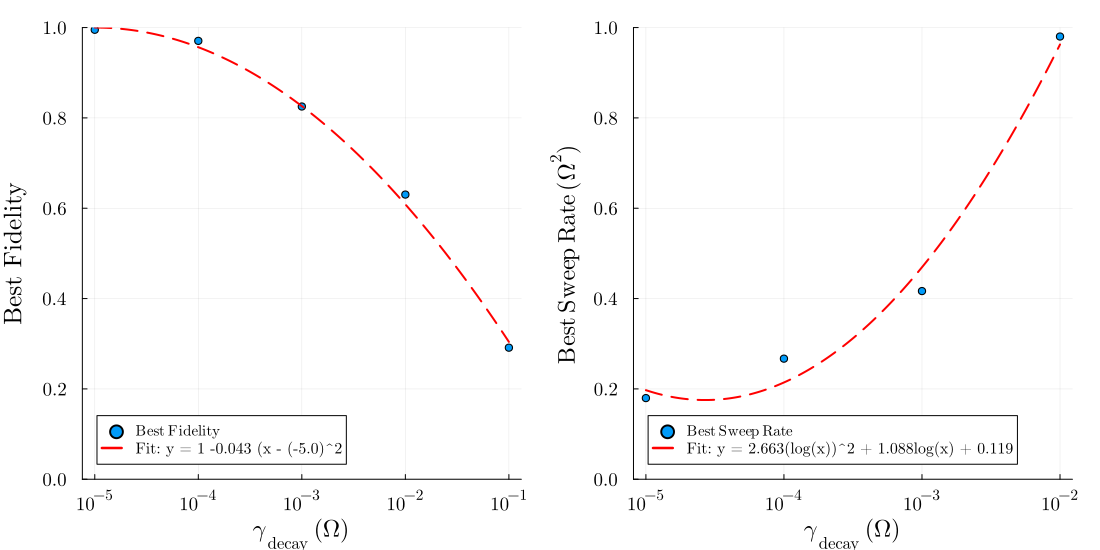

In [23]:
p = plot(fig, fig2;
    layout=(1,2),
    labelfontsize=16,
    tickfontsize=12,
    legendfontsize=10,
    lw=2,
    fontstyle="Computer Modern",
    link=:y,                # share y-scale
    size=(1100,550),
    ylim=[-0.0,1.0],
    markersize=4,
    fontsize=10,
    legend=:bottomleft,
    fontfamily="Computer Modern",
    margin=5Plots.mm)
savefig(p, "/Users/akashmalemath/Documents/master_work/rydberg_thesis/rydberg_qec/images/part3/num_sim/2_in_1.pdf")
display(p)

In [35]:
i=2
println("For the decay rate = $(decay[i]) the best fidelity is $(best_fidelity[i]) for the sweep rate is $(best_sweep_rate[i]). The time for adiabatic sweep is $(2*(1032-1000)/best_sweep_rate[i]) timesteps.")

For the decay rate = 0.0001 the best fidelity is 0.9705131317877066 for the sweep rate is 0.267017017017017. The time for adiabatic sweep is 239.6850984067479 timesteps.


### Analytical Decay

In [8]:
l = length(decay)
m = length(sweep_rate)

analytical_fidelity = Array{Float64}(undef,l,m)

Threads.@threads for idx in 1:l*m
    i = (idx-1) ÷ m + 1  # Calculate the row index
    j = (idx-1) % m + 1  # Calculate the column index

    a = decay[i]
    b = sweep_rate[j]
    T = 2*(1031-1000)/b
    analytical_fidelity[i,j] = real((1 - exp(-1/b)) * exp(-a * 0.5*T))
end

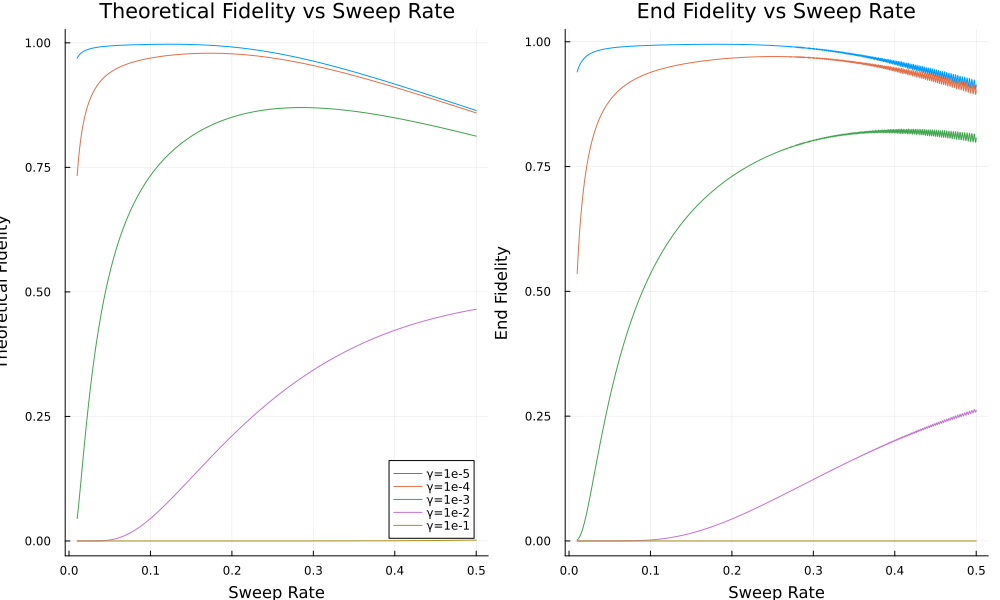

In [32]:
p1 = plot(sweep_rate,analytical_fidelity[1,:],label="γ=1e-5",xaxis="Sweep Rate",yaxis="Theoretical Fidelity",title="Theoretical Fidelity vs Sweep Rate",legend=:bottomright)
plot!(sweep_rate,analytical_fidelity[2,:],label="γ=1e-4",xaxis="Sweep Rate",yaxis="Theoretical Fidelity")
plot!(sweep_rate,analytical_fidelity[3,:],label="γ=1e-3",xaxis="Sweep Rate",yaxis="Theoretical Fidelity")
plot!(sweep_rate,analytical_fidelity[4,:],label="γ=1e-2",xaxis="Sweep Rate",yaxis="Theoretical Fidelity")
plot!(sweep_rate,analytical_fidelity[5,:],label="γ=1e-1",xaxis="Sweep Rate",yaxis="Theoretical Fidelity")

p2 = plot(sweep_rate,fidelity_end[1,:],label="γ = 1e-5",xlabel="Sweep Rate",ylabel="End Fidelity",title="End Fidelity vs Sweep Rate",legend=:false)
plot!(sweep_rate,fidelity_end[2,:],label="γ = 1e-4")
plot!(sweep_rate,fidelity_end[3,:],label="γ = 1e-3")
plot!(sweep_rate,fidelity_end[4,:],label="γ = 1e-2")
plot!(sweep_rate,fidelity_end[5,:],label="γ = 1e-1")

plot(p1,p2,layout=(1,2),size=(1000,600))

### Observations

In [19]:
println("1. End Fidelity calculated Numerically get messed up after sweep_rate of 0.25 because of two reasons:
a) Numerical Instability of the solver
b) Fast Sweep implying the process is tending to be more non-adiabatic\n
2. Theoretical End Fidelity fits almost with the Calculated End Fidelity, and the differences are because:
a. I assume that the decay starts at 0.5*T but to be precise, there is a finite probability of population in the rydberg state before this, so effectively decay starts at a earlier time.\n
3. The Best Sweep Rate goes linearly with increase in decay rate, approximately.
Note: The Best sweep rate for 10^-1 is not to be considered, given the numerical instabilities of the solver and probably needs more sweep_rate\n
")

1. End Fidelity calculated Numerically get messed up after sweep_rate of 0.25 because of two reasons:
a) Numerical Instability of the solver
b) Fast Sweep implying the process is tending to be more non-adiabatic

2. Theoretical End Fidelity fits almost with the Calculated End Fidelity, and the differences are because:
a. I assume that the decay starts at 0.5*T but to be precise, there is a finite probability of population in the rydberg state before this, so effectively decay starts at a earlier time.

3. The Best Sweep Rate goes linearly with increase in decay rate, approximately.
Note: The Best sweep rate for 10^-1 is not to be considered, given the numerical instabilities of the solver and probably needs more sweep_rate




## New Results from decay_endmax_fidelity.jld2

In [2]:
using Plots, JLD2, LaTeXStrings, FileIO,  PGFPlotsX, Polynomials
# pgfplotsx()

# @load "/home/agfleischhauer/roq68sum/rydberg_qec/codework/results_data/2atoms/decay_endmax_fidelity.jld2"
@load "/Users/akashmalemath/Documents/master_work/rydberg_thesis/rydberg_qec/codework/2atoms/results_data/decay_endmax_fidelity_new.jld2"
# @load "Z:/master_work/rydberg_qec/codework/2atoms/results_data/decay_endmax_fidelity.jld2"

decay = decay
sweep_rate = sweep_rate
fidelity_end = fidelity_end
max_fidelity = max_fidelity;

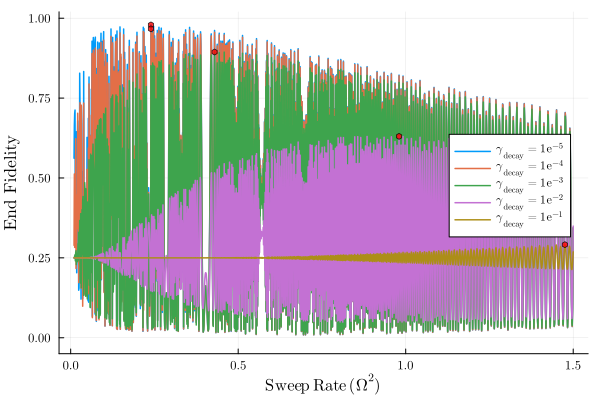

In [3]:
fig = plot(sweep_rate,fidelity_end[1,:],fontfamily="Computer Modern", fontsize=10, label=L"$\gamma_{\mathrm{decay}} = 1\mathrm{e}^{-5}$",
xlabel=L"\mathrm{Sweep\; Rate\;(\Omega^2)}",ylabel="End Fidelity",legend=:right,grid=true,ylim=[-0.05,1.02],lw=1.5)
plot!(sweep_rate,fidelity_end[2,:],label=L"$\gamma_{\mathrm{decay}} = 1\mathrm{e}^{-4}$",lw=1.5)
plot!(sweep_rate,fidelity_end[3,:],label=L"$\gamma_{\mathrm{decay}} = 1\mathrm{e}^{-3}$",lw=1.5)
plot!(sweep_rate,fidelity_end[4,:],label=L"$\gamma_{\mathrm{decay}} = 1\mathrm{e}^{-2}$",lw=1.5)
plot!(sweep_rate,fidelity_end[5,:],label=L"$\gamma_{\mathrm{decay}} = 1\mathrm{e}^{-1}$",lw=1.5)
#mark the ymax points for all the curves
for i in 1:length(decay)
    ymax = findmax(fidelity_end[i,:])
    scatter!([sweep_rate[ymax[2]]],[ymax[1]],label="",markershape=:hexagon,markersize=3,color=:red,alpha=0.8)
end
# annotation for the points
# annotate!([(sweep_rate[3],fidelity_end[1,3]+0.05,text("$(round(fidelity_end[1,3],digits=3))",:black,8,:center)),
# (sweep_rate[3],fidelity_end[2,3]+0.05,text("$(round(fidelity_end[2,3],digits=3))",:black,8,:center)),
# (sweep_rate[3],fidelity_end[3,3]+0.05,text("$(round(fidelity_end[3,3],digits=3))",:black,8,:center)),
# (sweep_rate[3],fidelity_end[4,3]+0.05,text("$(round(fidelity_end[4,3],digits=3))",:black,8,:center)),
# (sweep_rate[3],fidelity_end[5,3]+0.05,text("$(round(fidelity_end[5,3],digits=3))",:black,8,:center))])
# annotation for the points end
# title!("End fidelity for a sweep rate")

# savefig(fig,"/Users/akashmalemath/Documents/master_work/rydberg_thesis/rydberg_qec/images/part3/num_sim/2atom_end_fidelity_vs_sweep_rate.pdf")
display(fig)

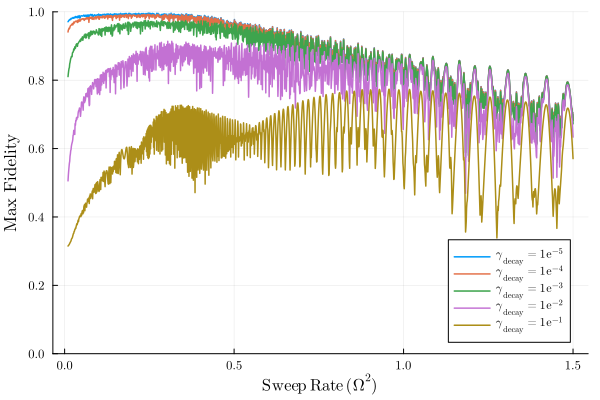

In [4]:
fig2 = plot(sweep_rate,max_fidelity[1,:],fontfamily="Computer Modern", fontsize=10, label=L"$\gamma_{\mathrm{decay}} = 1\mathrm{e}^{-5}$",
xlabel=L"\mathrm{Sweep\; Rate\;(\Omega^2)}",ylabel="Max Fidelity",legend=:bottomright,grid=true,ylim=[-0.0,1],lw=1.5)#,title="Max fidelity for a sweep rate")
plot!(sweep_rate,max_fidelity[2,:], label=L"$\gamma_{\mathrm{decay}} = 1\mathrm{e}^{-4}$",lw=1.5)
plot!(sweep_rate,max_fidelity[3,:], label=L"$\gamma_{\mathrm{decay}} = 1\mathrm{e}^{-3}$",lw=1.5)
plot!(sweep_rate,max_fidelity[4,:], label=L"$\gamma_{\mathrm{decay}} = 1\mathrm{e}^{-2}$",lw=1.5) 
plot!(sweep_rate,max_fidelity[5,:], label=L"$\gamma_{\mathrm{decay}} = 1\mathrm{e}^{-1}$",lw=1.5)
# savefig(fig2,"/Users/akashmalemath/Documents/master_work/rydberg_thesis/rydberg_qec/images/part3/num_sim/2atom_max_fidelity_vs_sweep_rate.pdf")
display(fig2)

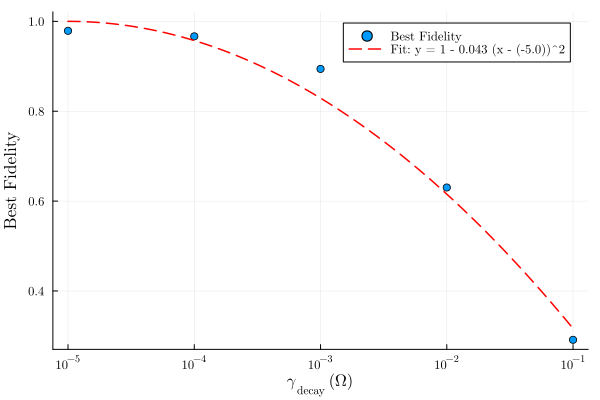

In [5]:
best_fidelity = maximum(fidelity_end[:,1:length(sweep_rate)],dims=2);
best_sweep_rate = []
for i in 1:length(decay)
    max_index = argmax(fidelity_end[i,1:length(sweep_rate)])
    push!(best_sweep_rate, sweep_rate[max_index])
end

fig = scatter(decay,best_fidelity,xscale=:log10, fontfamily="Computer Modern", fontsize=10, grid=true,
label="Best Fidelity", xlabel=L"\gamma_{\textrm{decay}}\;(\Omega)", ylabel="Best Fidelity",legend=:true, xticks=[1e-5, 1e-4, 1e-3, 1e-2, 1e-1])#, title="Best Fidelity Obtained vs Decay")
#fit a polynomial curve to the data
x = log10.(decay); y = vec(best_fidelity)
x0 = minimum(x)
ϕ  = (x .- x0).^2
c  = (ϕ \ (1 .- y))         # linear least squares
x_fit = range(minimum(x), maximum(x), length=300)
y_fit = 1 .- c .* (x_fit .- x0).^2

# println(coeffs(p))


plot!(10 .^ x_fit, y_fit, label="Fit: y = 1 - $(round(c, digits=3)) (x - ($(round(x0, digits=3))))^2", lw=1.5, lc=:red, linestyle=:dash)

# savefig(fig, "/Users/akashmalemath/Documents/master_work/rydberg_thesis/rydberg_qec/images/part3/num_sim/best_fidelity_vs_decay.pdf")
display(fig)

In [6]:
best_fidelity

5×1 Matrix{Float64}:
 0.9789848804484018
 0.966652540247019
 0.8941627420832141
 0.63025419731297
 0.29129329475756144

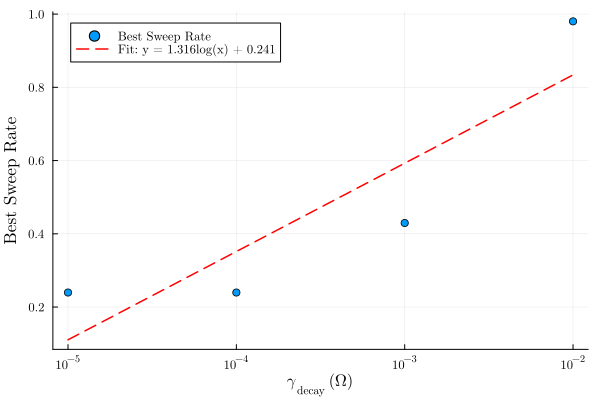

In [7]:
fig2 = scatter(decay[1:4], best_sweep_rate[1:4];
    xscale=:log10, label="Best Sweep Rate", fontsize=10, fontfamily="Computer Modern",
    xlabel=L"\gamma_{\textrm{decay}}\;(\Omega)", ylabel="Best Sweep Rate",
    legend=true, xticks=[1e-5, 1e-4, 1e-3, 1e-2, 1e-1])

# fit y ≈ a*log10(x) + b
x = log10.(decay[1:4])
y = Float64.(best_sweep_rate[1:4])
p = fit(Polynomial, x, y, 1)  # linear in log10(x)

x_fit_log = range(minimum(x), maximum(x), length=200)
y_fit = p.(x_fit_log)

# plot fit vs linear x; the axis handles the log scale
plot!(10 .^ x_fit_log, y_fit; label="Fit: y = $(round(p.coeffs[1], digits=3))log(x) + $(round(p.coeffs[2], digits=3))", color=:red, lw=1.5, linestyle=:dash)
display(fig2)
# savefig(fig2, "/Users/akashmalemath/Documents/master_work/rydberg_thesis/rydberg_qec/images/part3/num_sim/best_sweep_rate_vs_decay.pdf")

In [8]:
best_sweep_rate[4]

0.980140093395597

## Results from dephase_endmax_fidelity

In [10]:
using Plots, JLD2, LaTeXStrings, FileIO

@load "/Users/akashmalemath/Documents/master_work/rydberg_qec/codework/2atoms/results_data/dephase_endmax_fidelity.jld2"

dephase = dephase
sweep_rate = sweep_rate
fidelity_end = fidelity_end
max_fidelity = max_fidelity;

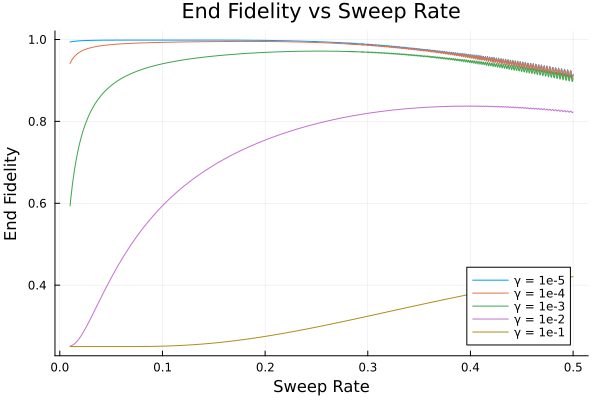

In [11]:
plot(sweep_rate,fidelity_end[1,:],label="γ = 1e-5",xlabel="Sweep Rate",ylabel="End Fidelity",title="End Fidelity vs Sweep Rate",legend=:true)
plot!(sweep_rate,fidelity_end[2,:],label="γ = 1e-4")
plot!(sweep_rate,fidelity_end[3,:],label="γ = 1e-3")
plot!(sweep_rate,fidelity_end[4,:],label="γ = 1e-2")
plot!(sweep_rate,fidelity_end[5,:],label="γ = 1e-1")

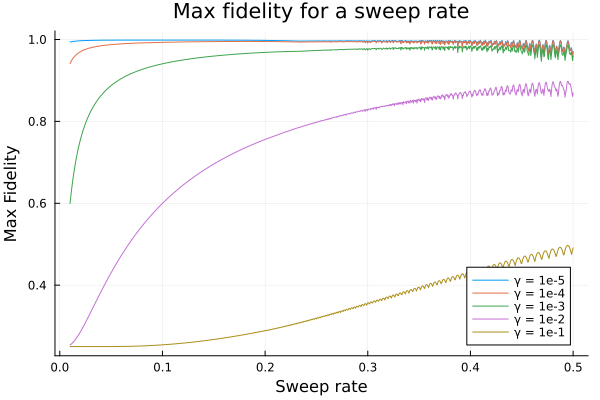

In [12]:
plot(sweep_rate,max_fidelity[1,:], label="γ = 1e-5", xlabel="Sweep rate", ylabel="Max Fidelity", title="Max fidelity for a sweep rate", legend=:bottomright)
plot!(sweep_rate,max_fidelity[2,:], label="γ = 1e-4", xlabel="Sweep rate", ylabel="Max Fidelity")
plot!(sweep_rate,max_fidelity[3,:], label="γ = 1e-3", xlabel="Sweep rate", ylabel="Max Fidelity")
plot!(sweep_rate,max_fidelity[4,:], label="γ = 1e-2", xlabel="Sweep rate", ylabel="Max Fidelity") 
plot!(sweep_rate,max_fidelity[5,:], label="γ = 1e-1", xlabel="Sweep rate", ylabel="Max Fidelity")

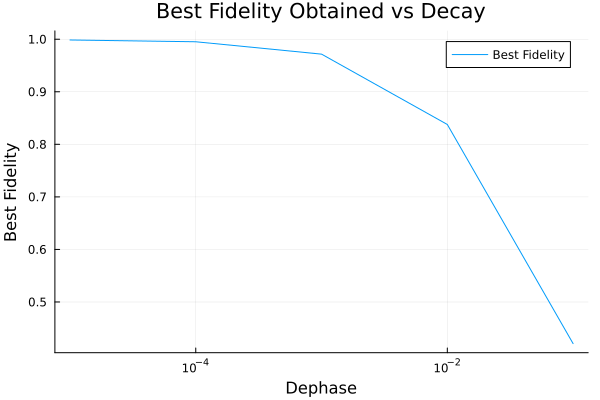

In [13]:
best_fidelity = maximum(fidelity_end[:,1:length(sweep_rate)],dims=2);
best_sweep_rate = []
for i in 1:length(dephase)
    max_index = argmax(fidelity_end[i,1:length(sweep_rate)])
    push!(best_sweep_rate, sweep_rate[max_index])
end

plot(dephase,best_fidelity,xscale=:log10, label="Best Fidelity", xlabel="Dephase", ylabel="Best Fidelity", title="Best Fidelity Obtained vs Decay", legend=:topright)

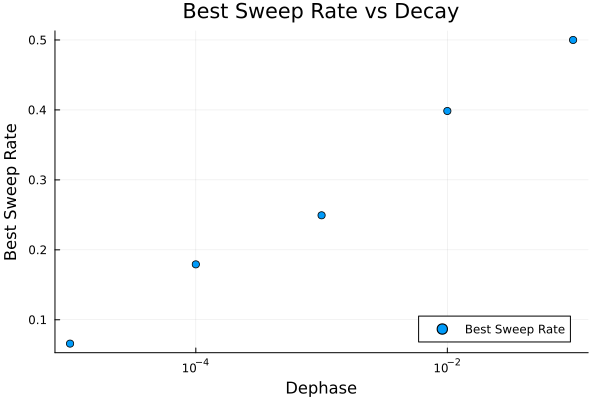

In [14]:
scatter(dephase,best_sweep_rate, xscale=:log10, label="Best Sweep Rate", xlabel="Dephase", ylabel="Best Sweep Rate", title="Best Sweep Rate vs Decay", legend=:bottomright)

In [15]:
i=1
println("For the dephase rate = $(dephase[i]) the best fidelity is $(best_fidelity[i]) for the sweep rate is $(best_sweep_rate[i]). The time for adiabatic sweep is $(2*(1032-1000)/best_sweep_rate[i]) timesteps.")

For the dephase rate = 1.0e-5 the best fidelity is 0.9985654412902065 for the sweep rate is 0.06591591591591592. The time for adiabatic sweep is 970.9339407744875 timesteps.
